In [12]:
import sys
import os
sys.path.append(os.path.abspath(".."))

import Hamiltonian as ham
import PauliStrings as pauli_strings
import scipy.sparse as sp
import numpy as np
from matplotlib import pyplot as plt
import Evolution as evol

In [13]:
def fidelity_pure(psi,phi):
    '''
    input values should be column vectors
    '''
    F=np.abs(psi.conj().T@phi)**2
    return F[0,0]

def random_state(n):
    psi = np.transpose(np.random.randn(2**n) + 1j*np.random.randn(2**n))
    return sp.csc_matrix(psi / np.linalg.norm(psi))


In [14]:
def QITE_ACQ_Cluster_evol(lam,n_qubits,D):
    #trotter params
    H,H_trot=ham.ClusterIsing(lam,n_qubits,T=3)
    print('Computing Eigs')
    EH,VH = np.linalg.eigh(H.todense())
    psigs=VH[:,0]
    E_gs=EH[0]

    #evolution parameters
    dt=0.1
    N=100
    tmax=dt*N
    t=0 + np.arange(0, N+1) *dt

    #initial state
    psi0np=np.zeros((2**n_qubits,1),dtype=complex)
    psi0np[0]=1
    psi_0=sp.csc_matrix(psi0np/np.linalg.norm(psi0np))
    #psi_0=np.transpose(random_state(n_qubits))

    #QITE and ITE evolution
    print("Computing QITE")
    NQ=20
    EQ,psi_QITE,aQITE = evol.QITE(n_qubits,H,H_trot,D,psi_0,NQ,dt,vervose=False,OBC=False)
    print("ACQ QITE")
    dt_ACQ=0.05
    E_ACQ,psi_ACQ,indx,tACQ,aACQ = evol.ACQ_QC(n_qubits,H,H_trot,D,psi_0,N,dt_ACQ,OBC=False)

    #Fidelities
    F_ACQ=np.zeros(N+1)
    for i in range(N+1):
        F_ACQ[i]=fidelity_pure(psigs,psi_ACQ[:,i].todense())

    #Fidelities
    F_Q=np.zeros(len(EQ))
    for i in range(len(EQ)):
        F_Q[i]=fidelity_pure(psigs,psi_QITE[:,i].todense())

    return EQ, F_Q, E_ACQ[indx], F_ACQ[indx]

In [15]:
def QITE_ACQ_Cluster(lam,n_qubits,D):
    #trotter params
    H,H_trot=ham.ClusterIsing(lam,n_qubits,T=3)
    print('Computing Eigs')
    EH,VH = np.linalg.eigh(H.todense())
    psigs=VH[:,0]
    E_gs=EH[0]

    #evolution parameters
    dt=0.1
    N=100
    tmax=dt*N
    t=0 + np.arange(0, N+1) *dt

    #initial state
    psi0np=np.zeros((2**n_qubits,1),dtype=complex)
    psi0np[0]=1
    psi_0=sp.csc_matrix(psi0np/np.linalg.norm(psi0np))
    #psi_0=np.transpose(random_state(n_qubits))

    #QITE and ITE evolution
    print("Computing QITE")
    NQ=20
    EQ,psi_QITE,aQITE = evol.QITE(n_qubits,H,H_trot,D,psi_0,NQ,dt,vervose=False,OBC=False)
    print("ACQ QITE")
    dt_ACQ=0.05
    E_ACQ,psi_ACQ,indx,tACQ,aACQ = evol.ACQ_QC(n_qubits,H,H_trot,D,psi_0,N,dt_ACQ,OBC=False)

    #Fidelities
    F_ACQ=np.zeros(N+1)
    for i in range(N+1):
        F_ACQ[i]=fidelity_pure(psigs,psi_ACQ[:,i].todense())

    #Fidelities
    F_Q=np.zeros(len(EQ))
    for i in range(len(EQ)):
        F_Q[i]=fidelity_pure(psigs,psi_QITE[:,i].todense())

    return EQ[-1], F_Q[-1], E_ACQ[-1], F_ACQ[indx[-1]]

## Plots AntiFerro Phase CI model

In [16]:
lam=1.5
N=range(6,9)

D=3
FQ2=np.zeros(len(N))
EQ2=np.zeros(len(N))
FACQ2=np.zeros(len(N))
EACQ2=np.zeros(len(N))
for i in range(len(N)):
    EQ2[i], FQ2[i], EACQ2[i], FACQ2[i] = QITE_ACQ_Cluster(lam,N[i],D)
 
D=5
FQ4=np.zeros(len(N))
EQ4=np.zeros(len(N))
FACQ4=np.zeros(len(N))
EACQ4=np.zeros(len(N))
for i in range(len(N)):
    EQ4[i], FQ4[i], EACQ4[i], FACQ4[i] = QITE_ACQ_Cluster(lam,N[i],D)

Computing Eigs
Computing QITE
ACQ QITE
Computing U at step 0
Computing U at step 3
Computing U at step 8
Computing U at step 12
Computing U at step 17
Computing U at step 20
Computing U at step 29
Computing U at step 34
Computing U at step 42
Computing U at step 45
Computing U at step 57
Computing U at step 61
Computing U at step 68
Computing U at step 71
Computing U at step 84
Computing U at step 88
Computing U at step 93
Computing U at step 97
Computing Eigs
Computing QITE
Energy doubly increased at step 9
ACQ QITE
Computing U at step 0
Computing U at step 3
Computing U at step 7
Computing U at step 12
Computing U at step 17
Computing U at step 18
Energy doubly increased, stopping criteria activated at step 19
Computing Eigs
Computing QITE
Energy doubly increased at step 11
ACQ QITE
Computing U at step 0
Computing U at step 3
Computing U at step 8
Computing U at step 13
Computing U at step 18
Computing U at step 21
Computing U at step 24
Energy doubly increased, stopping criteria act

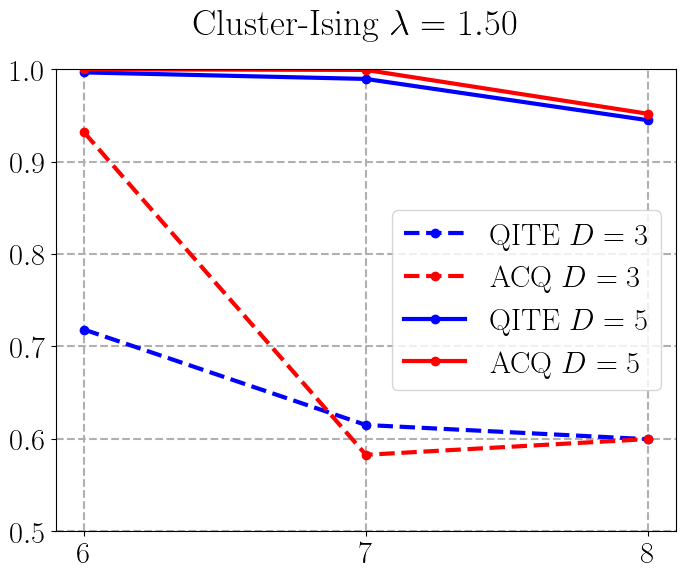

In [17]:
plt.figure(figsize=(8, 6))
plt.rcParams.update({
    "text.usetex": True,
})
font = {'family' : 'normal',
        'weight' : 'bold',
        'size'   : 22}

plt.rc('font', **font)
plt.suptitle("Cluster-Ising $\\lambda=%.2f$"%(lam))

plt.plot(N,FQ2,'--bo',linewidth=3,label='QITE $D=%d$'%3)
plt.plot(N,FACQ2,'--ro',linewidth=3,label='ACQ $D=%d$'%3)

plt.plot(N,FQ4,'-bo',linewidth=3,label='QITE $D=%d$'%5)
plt.plot(N,FACQ4,'-ro',linewidth=3,label='ACQ $D=%d$'%5)
plt.legend()
plt.xticks(N)
plt.ylim(0.5,1)
plt.grid(linestyle = '--', linewidth = 1.5)
plt.savefig("CI_Antiferro_QC.png")

# Plots Cluster Phase CI model

In [18]:
lam=0.5
N=range(6,9)

D=3
FQ2=np.zeros(len(N))
EQ2=np.zeros(len(N))
FACQ2=np.zeros(len(N))
EACQ2=np.zeros(len(N))
for i in range(len(N)):
    EQ2[i], FQ2[i], EACQ2[i], FACQ2[i] = QITE_ACQ_Cluster(lam,N[i],D)
 
D=5
FQ4=np.zeros(len(N))
EQ4=np.zeros(len(N))
FACQ4=np.zeros(len(N))
EACQ4=np.zeros(len(N))
for i in range(len(N)):
    EQ4[i], FQ4[i], EACQ4[i], FACQ4[i] = QITE_ACQ_Cluster(lam,N[i],D)

Computing Eigs
Computing QITE
ACQ QITE
Computing U at step 0
Computing U at step 5
Computing U at step 15
Computing U at step 28
Computing U at step 36
Computing U at step 42
Computing U at step 50
Computing U at step 55
Computing U at step 64
Computing U at step 69
Computing U at step 76
Computing U at step 82
Computing U at step 88
Computing U at step 94
Computing Eigs
Computing QITE
Energy doubly increased at step 15
ACQ QITE
Computing U at step 0
Computing U at step 5
Computing U at step 15
Computing U at step 26
Computing U at step 32
Computing U at step 35
Energy doubly increased, stopping criteria activated at step 36
Computing Eigs
Computing QITE
ACQ QITE
Computing U at step 0
Computing U at step 5
Computing U at step 15
Computing U at step 27
Computing U at step 34
Computing U at step 40
Computing U at step 43
Computing U at step 45
Computing U at step 46
Computing U at step 47
Energy doubly increased, stopping criteria activated at step 48
Computing Eigs
Computing QITE
ACQ QI

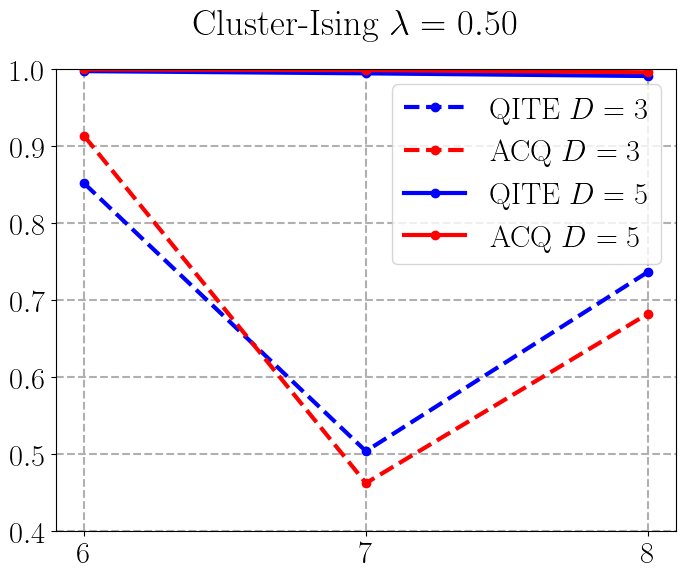

In [22]:
plt.figure(figsize=(8, 6))
plt.rcParams.update({
    "text.usetex": True,
})
font = {'family' : 'normal',
        'weight' : 'bold',
        'size'   : 22}

plt.rc('font', **font)
plt.suptitle("Cluster-Ising $\\lambda=%.2f$"%(lam))

plt.plot(N,FQ2,'--bo',linewidth=3,label='QITE $D=%d$'%3)
plt.plot(N,FACQ2,'--ro',linewidth=3,label='ACQ $D=%d$'%3)
plt.plot(N,FQ4,'-bo',linewidth=3,label='QITE $D=%d$'%5)
plt.plot(N,FACQ4,'-ro',linewidth=3,label='ACQ $D=%d$'%5)
plt.legend()
plt.xticks(N)
plt.ylim(0.4,1)
plt.grid(linestyle = '--', linewidth = 1.5)
plt.savefig("CI_Cluster_QC.png")

# Example During Evolution

In [20]:
lam=0.5
n_qubits=8
D=3
EQ,F_Q,E_ACQ,F_ACQ=QITE_ACQ_Cluster_evol(lam,n_qubits,D)

Computing Eigs
Computing QITE
ACQ QITE
Computing U at step 0
Computing U at step 5
Computing U at step 15
Computing U at step 27
Computing U at step 34
Computing U at step 40
Computing U at step 43
Computing U at step 45
Computing U at step 46
Computing U at step 47
Energy doubly increased, stopping criteria activated at step 48


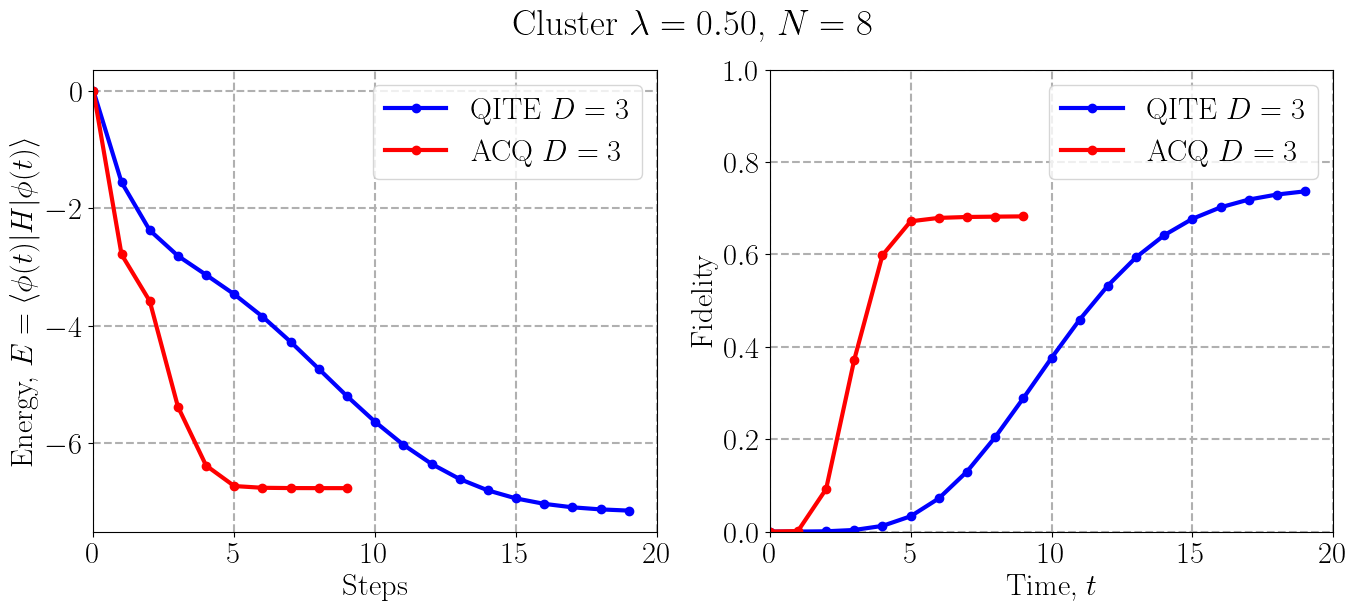

In [21]:
plt.figure(figsize=(16, 6))
plt.rcParams.update({
    "text.usetex": True,
})
font = {'family' : 'normal',
        'weight' : 'bold',
        'size'   : 22}

plt.rc('font', **font)
plt.suptitle("Cluster $\\lambda=%.2f$, $N=%d$"%(lam,n_qubits))

plt.subplot(1,2,1)
plt.plot(EQ,'-bo',linewidth=3,label='QITE $D=%d$'%D)
plt.plot(E_ACQ,'-ro',linewidth=3,label='ACQ $D=%d$'%D)
plt.xlabel("Steps")
plt.ylabel("Energy, $E=\\langle \\phi(t)|H|\\phi(t)\\rangle$")
plt.xlim(0,max(len(E_ACQ),len(EQ)))
plt.legend()
plt.grid(linestyle = '--', linewidth = 1.5)

plt.subplot(1,2,2)
plt.plot(F_Q,'-bo',linewidth=3,label='QITE  $D=%d$'%D)
plt.plot(F_ACQ,'-ro',linewidth=3,label='ACQ  $D=%d$'%D)
plt.xlabel("Time, $t$")
plt.ylabel("Fidelity")
plt.xlim(0,max(len(E_ACQ),len(EQ)))
plt.ylim(0,1)
plt.legend()
plt.grid(linestyle = '--', linewidth = 1.5)
#plt.savefig("adaptive_QITE_N12D4.png")